# I. Data preparation

Loading data from source

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf
import pathlib
import tensorflow.keras.layers as tfl
import os
import pickle
import keras_tuner as kt

In [2]:
from zipfile import ZipFile

# uncomment to load data
# zip_dir = 'data/emotion_data.zip'
# extraction_dir = ""

# with ZipFile(zip_dir, 'r') as zip_object:
#     zip_object.extractall(path=extraction_dir)

# print(f"All files extracted from '{zip_dir}' to '{extraction_dir}'.")

data_dir = pathlib.Path("emotion_data/")

Viewing training data

In [3]:
num_train_images = len(list(data_dir.glob("train/*/*")))
print("Images:", num_train_images)
print("Classes:", list(data_dir.glob("train/*")))

Images: 28709
Classes: [WindowsPath('emotion_data/train/angry'), WindowsPath('emotion_data/train/disgust'), WindowsPath('emotion_data/train/fear'), WindowsPath('emotion_data/train/happy'), WindowsPath('emotion_data/train/neutral'), WindowsPath('emotion_data/train/sad'), WindowsPath('emotion_data/train/surprise')]


In [4]:
train_dir = pathlib.Path("emotion_data/train")

batch_size = 64
# img_height = 180
# img_width = 180
val_split = 0.2

train_ds, val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=val_split,
    subset="both",
    seed=91,
    image_size=(48,48),
    batch_size=batch_size,
    color_mode='grayscale',
    shuffle=True,
    label_mode='categorical'
)
# train_ds = train_ds.shuffle(buffer_size=len(list(train_ds.as_numpy_iterator())))
# val_ds = val_ds.shuffle(buffer_size=len(list(val_ds.as_numpy_iterator())))

Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Using 5741 files for validation.


## Training preparation

In [5]:
class_names = train_ds.class_names
image_shape = None
labels_shape = None
num_classes = len(class_names)

for image_batch, labels_batch in train_ds:
    image_shape = image_batch.shape[1:]
    labels_shape = labels_batch.numpy().reshape(-1, 1).shape[1:]
    break

print(class_names, image_shape, labels_shape)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise'] (48, 48, 1) (1,)


Dataset configuration

In [6]:
AUTOTUNE = tf.data.AUTOTUNE

subset_reduction_factor_train = 0.2
subset_reduction_factor_val = 0.2
num_batches = num_train_images//batch_size

train_subset_size = int(num_batches*(1-val_split)*subset_reduction_factor_train)
val_subset_size = int(num_batches*val_split*subset_reduction_factor_val)

used_train_ds = train_ds.cache().take(train_subset_size).prefetch(buffer_size=AUTOTUNE)
used_val_ds = val_ds.cache().take(val_subset_size).prefetch(buffer_size=AUTOTUNE)

train_subset_size, val_subset_size

(71, 17)

Viewing training and validation data to ensure similar representations

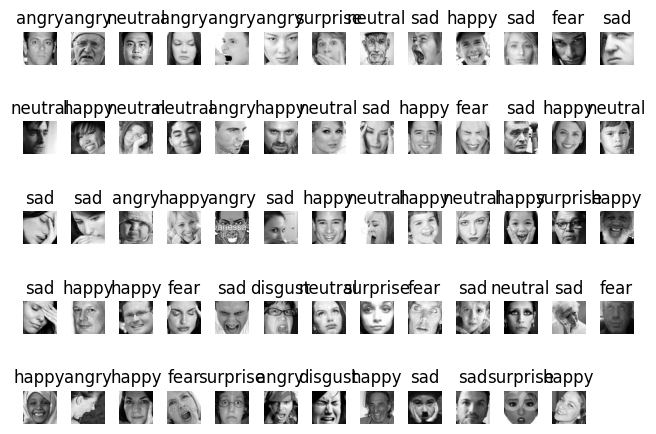

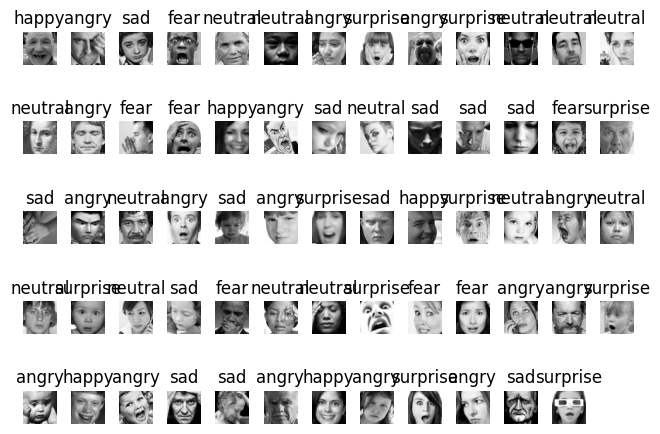

In [7]:
def view_batch(ds, batch_num):
    c = 0
    for image_batch, labels_batch in ds:
        if batch_num != c:
            c+=1
            continue
        # print(image_batch.shape[0], int(np.ceil(image_batch.shape[0]/5)))
        for index, image in enumerate(image_batch):
            # print(labels_batch[index])
            label = np.argmax(labels_batch[index].numpy())
            ax = plt.subplot(5, int(np.ceil(image_batch.shape[0]/5)), index+1)
            ax.imshow(image.numpy().astype("uint8"), cmap="gray")
            ax.axis("off")
            ax.set_title(class_names[int(label)])
        break
    plt.tight_layout()
    plt.show()

def view_batch_shape(ds):
    for i, j in ds:
        print(i.shape, j.shape)
        break

view_batch(used_train_ds, 1)
view_batch(used_val_ds, 1)

# 2. Training

## Utilities

### Save/load utilities

Every time a distinct model is trained and/or used for observations, call `set_save_paths(model_name: str)`. Use the paths `checkpoint_path` and `base_path`, as well as the subroutines below, accordingly.

Information that can be saved and loaded are the training history and the parameters of a model.

By default, models load pretrained weights. Cells containing `model.fit()` can be optionally run once or multiple times by changing the cell format from raw to Python.

To train a fresh model, delete/rename the `training` folder (or its specific subfolders)

In [101]:
base_path:str = None
checkpoint_path:str = None
current_model_name:str = None

In [102]:
def create_path(filepath, isfile=True):
    path = pathlib.Path(filepath)
    if isfile:
        path.parent.mkdir(parents=True, exist_ok=True)
        path.touch(exist_ok=True)
    else:
        path.mkdir(parents=True, exist_ok=True)

def set_save_paths(model_name:tf.keras.Model):
    global checkpoint_path
    global base_path
    global current_model_name
    current_model_name = model_name
    base_path = f"training/{model_name}"
    checkpoint_path = f"{base_path}/parameters.weights.h5"
    print("Save path now belongs to", current_model_name)

def load_parameters(model, custom_model_name=None):
    global checkpoint_path
    global base_path
    global current_model_name

    used_model_name = custom_model_name if custom_model_name != None else current_model_name
    used_checkpoint_path = f"training/{used_model_name}/parameters.weights.h5"

    if not os.path.isfile(used_checkpoint_path):
        print("No parameters found, no parameters loaded from", used_model_name)
        return

    print("Loading parameters of", used_model_name, f"({'Custom' if custom_model_name != None else 'Default'})")

    model.load_weights(used_checkpoint_path, skip_mismatch=True)

def save_object(object, name="history"):
    global checkpoint_path
    global base_path
    global current_model_name

    path = f"{base_path}/{name}"

    create_path(path, isfile=False)

    all_items = os.listdir(path)
    files_only = [os.path.join(path, item) for item in all_items]
    files_only = [item for item in files_only if os.path.isfile(item)]
    
    filepath = f"{path}/{len(files_only)}.pickle"
    create_path(filepath)
    
    print(f"Saving {name} of", current_model_name)
    with open(filepath, 'wb') as f:
        pickle.dump(object.history if name=="history" else object, f)

def load_object(name="history"):
    global checkpoint_path
    global base_path
    global current_model_name
    
    path = f"{base_path}/{name}"

    print(f"Loading {name} of", current_model_name)
    histories = []
    for i in os.listdir(path):
        curpath = os.path.join(path, i)
        if not os.path.isfile(curpath):
            continue
        with open(curpath, 'rb') as f:
            histories.append(pickle.load(f))
    return histories

def plot_object(chosen_attributes, ylim1=0, ylim2=1, name="history"):
    objects = load_object(name)
    for i in chosen_attributes:
        attribute_list = [item for cur_object in objects for item in cur_object[i]]
        plt.plot(np.arange(len(attribute_list)), attribute_list, label=i)
    plt.legend()
    plt.ylim(ylim1, ylim2)
    plt.title(f"{name} of {current_model_name}")
    plt.show()

## Transfer learning approaches

### ResNet50

In [ ]:
set_save_paths("base_resnet")
base_model = tf.keras.applications.ResNet50(
    include_top=False,
    input_shape=image_shape,
    weights='imagenet'
)

base_model.trainable = False 

INPUTS = tf.keras.Input(shape=image_shape)
L = tf.keras.layers.Rescaling(1./255)(INPUTS)
L = base_model(L, training=False)
L = tf.keras.layers.GlobalAveragePooling2D()(L)
L = tf.keras.layers.Dense(128, activation='relu')(L)
L = tf.keras.layers.Dropout(0.5)(L)
OUTPUTS = tf.keras.layers.Dense(num_classes, activation='softmax')(L)

model = tf.keras.Model(INPUTS, OUTPUTS)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.Catego,
    metrics=['accuracy']
)

load_parameters(model)
history = model.fit(train_ds, validation_data=val_ds, epochs=20)
save_object(history)

plot_object(["val_accuracy", "accuracy"])
plot_object(["val_loss", "loss"], None, None)

Fine-tuning ResNet50:

In [ ]:

base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path, save_weights_only=True, verbose=0)
es_callback = tf.keras.callbacks.EarlyStopping(
    monitor='loss',  # Metric to monitor (e.g., validation loss)
    patience=10,         # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True  # Restores model weights from the epoch with the best monitored value
)

history = model.fit(train_ds, validation_data=val_ds, epochs=20, callbacks=[cp_callback, es_callback])




# 3. Testing and evaluation

## On test data

In [ ]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    pathlib.Path("emotion_data/test"),
    seed=91,
    image_size=(48,48),
    batch_size=10000,
    color_mode='grayscale',
    shuffle=True,
    label_mode='categorical'
)

L = None
y = None

for x_batch, y_batch in test_ds:
    L = x_batch.numpy()
    y = y_batch.numpy()
    break

L.shape, y.shape

Found 7178 files belonging to 7 classes.


((7178, 48, 48, 1), (7178, 7))

In [107]:
model.evaluate(test_ds, return_dict=True)

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.5070 - loss: 1.6791


{'accuracy': 0.5069657564163208, 'loss': 1.6791218519210815}

This confirms that the model has 50% accuracy.

## Confusion matrix

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


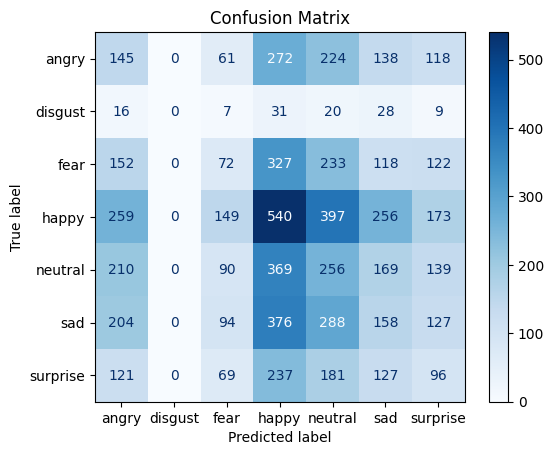

In [58]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(test_ds), axis=1)
y_true = np.argmax(y, axis=1)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

Basically every other experiment on this dataset would tell you that `happy` is the most easily recognized and `disgust` is the least. This is true for this experiment as well.

## Testing own data
Image is of my friends

Found 24 files belonging to 7 classes.


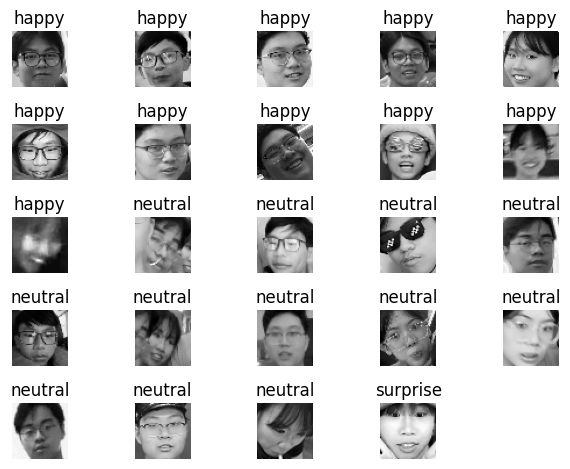

In [109]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    pathlib.Path("test_data"),
    seed=91,
    image_size=(48,48),
    batch_size=30,
    color_mode='grayscale',
    shuffle=False,
    label_mode='categorical'
)

view_batch(test_ds, 0)

In [110]:
model.evaluate(test_ds, return_dict=True)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.5417 - loss: 1.6985


{'accuracy': 0.5416666865348816, 'loss': 1.6985472440719604}

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


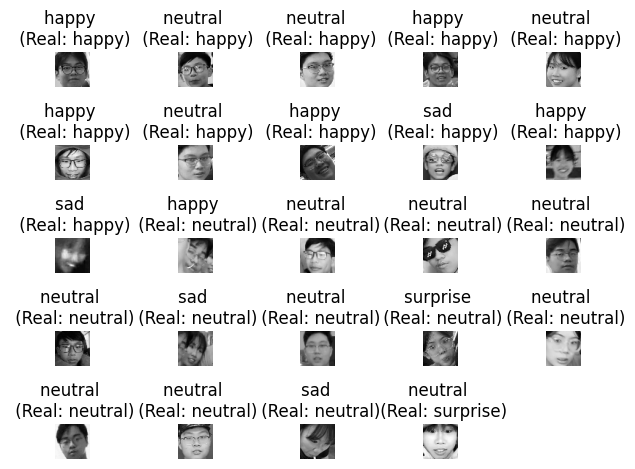

In [113]:

y_pred = np.argmax(model.predict(test_ds), axis=1)
for image_batch, labels_batch in test_ds:
    for index, image in enumerate(image_batch):
        label = np.argmax(labels_batch[index].numpy())
        ax = plt.subplot(5, int(np.ceil(image_batch.shape[0]/5)), index+1)
        ax.imshow(image.numpy().astype("uint8"), cmap="gray")
        ax.axis("off")
        ax.set_title(f"{class_names[int(y_pred[index])]} \n (Real: {class_names[int(label)]})")
    break
plt.tight_layout()
plt.show()

# 4. Conclusion
Just one thing: Training from scratch is really hard